In [1]:
import xarray as xr
import numpy as np
import matplotlib, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import textwrap
import math
from datetime import datetime, timezone, timedelta
from collections import defaultdict

IBTrACS_path = 'IBTrACS.since1980.v04r01.nc'
IBTrACS_ds = xr.open_dataset(IBTrACS_path).load()

## Storm Index - Year

#### 1980-2000

* 1: 1980
* 110: 1981
* 220: 1982
* 336: 1983
* 435: 1984
* 553: 1985
* 676: 1986
* 787: 1987
* 891: 1988
* 1001: 1989
* 1131: 1990
* 1248: 1991
* 1347: 1992
* 1470: 1993
* 1569: 1994
* 1684: 1995
* 1780: 1996
* 1903: 1997
* 2011: 1998
* 2118: 1999

#### 2000-2025

* 2221: 2000
* 2333: 2001
* 2441: 2002
* 2539: 2003
* 2644: 2004
* 2747: 2005
* 2862: 2006
* 2963: 2007
* 3057: 2008
* 3156: 2009
* 3256: 2010
* 3344: 2011
* 3439: 2012
* 3533: 2013
* 3635: 2014
* 3724: 2015
* 3836: 2016
* 3932: 2017
* 4040: 2018
* 4157: 2019
* 4266: 2020
* 4387: 2021
* 4493: 2022
* 4604: 2023
* 4692: 2024
* 4785: 2025
* 4787

## Auxiliary Methods

### Datetime conversions

In [2]:
'''
"to_datetime" converts a numpy datetime64 object (dtype of IBTrACS and CERES) to a python datetime object
(dtype of time in generated database).

Input:
  date - a np.datetime64 object
Output:
  DATE - a python datetime object
      
Source: https://gist.github.com/blaylockbk/1677b446bc741ee2db3e943ab7e4cabd?permalink_comment_id=3775327
'''
def to_datetime(date):
    timestamp = int((date - np.datetime64('1970-01-01T00:00:00'))
                 / np.timedelta64(1, 's'))
    return datetime.utcfromtimestamp(timestamp)


'''
"to_local_time" converts the IBTrACS time values for a storm (originally UTC time) into its local time.

Input:
  time_values - IBrACS time data
  longitude - IBTrACS storm longitude
Output:
  lt - local time data as numpy datetime64 object
  
'''
def to_local_time(time_values, longitude):
    datetimes = to_datetime(time_values)
    
    # convert to longitude west if needed
    if longitude > 180:
        longitude = longitude - 360
        lt = datetimes - timedelta(hours=int(longitude/15))
    else:
        lt = datetimes + timedelta(hours=int(longitude/15))
    
    return np.datetime64(lt)

### Print histograms

In [3]:
'''
"print_hist" creates the histogram visualization
'''

def print_hist(gen_times, years, num_blocks, thresh):
    fig, ax = plt.subplots(figsize=(4,4))
    
    if num_blocks != 0:
        if num_blocks == 4:
            categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
        elif num_blocks == 8:
            categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']
        ax.bar(categories, gen_times)
        ax.set_xlabel('Local Time Bin (right incl.)')
        plt.setp(ax.get_xticklabels(), rotation=45)
        
    else:
        #ax.scatter(np.arange(gen_times.size), gen_times)
        ax.bar(np.arange(gen_times.size), gen_times)
        ax.set_xlabel('Local Hour')

    ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    #ax.minorticks_off()
    plt.suptitle(years + ': N = ' + str(np.sum(gen_times)))
    #plt.title("First Record", ha='center', y=1.0, fontsize=12, color='gray')
    plt.title("Threshold: " + str(thresh) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
    ax.set_ylabel('Genesis Frequency')
    
    plt.show()

In [4]:
'''
"print_hist_err" creates the histogram visualization with error bars
'''

def print_hist_err(gen_means, errors, sample_size, title, num_blocks, thresh):
    fig, ax = plt.subplots(figsize=(4,4))
    
    if num_blocks == 4:
        categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
    elif num_blocks == 8:
        categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']
    ax.bar(categories, gen_means, yerr=errors, capsize=3, color='skyblue', ecolor='black')
    ax.set_xlabel('Local Time Bin (right incl.)')
    plt.setp(ax.get_xticklabels(), rotation=45)

    ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    plt.suptitle(title + ': N = ' + str(sample_size))
    plt.title("Threshold: " + str(thresh) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
    ax.set_ylabel('Genesis Frequency')
    
    plt.show()

In [9]:
'''
"print_hist_basin" creates the histogram visualization for a specific basin
'''

def print_hist_basin(gen_times, years, num_blocks, thresh, basin):
    #print_hist(gen_times, years, num_blocks, thresh)

    fig, ax = plt.subplots(figsize=(4,4))
    
    if num_blocks != 0:
        if num_blocks == 4:
            categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
        elif num_blocks == 8:
            categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']
        ax.bar(categories, gen_times)
        ax.set_xlabel('Local Time Bin (right incl.)')
        plt.setp(ax.get_xticklabels(), rotation=45)
        
    else:
        #ax.scatter(np.arange(gen_times.size), gen_times)
        ax.bar(np.arange(gen_times.size), gen_times)
        ax.set_xlabel('Local Hour')

    ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
    #ax.minorticks_off()
    if basin == 'all':
        plt.suptitle(basin + ' Basin ' + years + ': N = ' + str(np.sum(gen_times)))
    else:
        plt.suptitle(basin.decode("utf-8") + ' Basin ' + years + ': N = ' + str(np.sum(gen_times)))
    #plt.title("First Record", ha='center', y=1.0, fontsize=12, color='gray')
    plt.title("Threshold: " + str(thresh) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
    ax.set_ylabel('Genesis Frequency')
    
    plt.show()

### Histogram Helper Methods

In [6]:
def sort_genesis(num_blocks, genesis):
    block = 0
    # organize genesis hour into time block (right inclusive)
    
    if num_blocks == 8:
        # time blocks: 12am-6am, 6am-12pm, 12pm-6pm, 6pm-12am
        if genesis <= 6 and genesis > 3:
            block = 1;
        elif genesis <= 9 and genesis > 6:
            block = 2;
        elif genesis <= 12 and genesis > 9:
            block = 3;
        elif genesis <= 15 and genesis > 12:
            block = 4;
        elif genesis <= 18 and genesis > 15:
            block = 5;
        elif genesis <= 21 and genesis > 18:
            block = 6;
        elif genesis > 21 or genesis == 0:
            block = 7;

    elif num_blocks == 4:
        # time blocks: 12am-6am, 6am-12pm, 12pm-6pm, 6pm-12am
        if genesis <= 12 and genesis > 6:
            block = 1;
        elif genesis <= 18 and genesis > 12:
            block = 2;
        elif genesis > 18 or genesis == 0:
            block = 3;
            
    return block

# Global Distributions
#### Local time of day vs. probability density of genesis

## First Record

In [ ]:
# First Record

# user input: num_blocks (number of time blocks), sindices
num_blocks = 8
sindices = np.arange(1, 4787)
# ------------------------------------------------------------------------------------------------
# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)

count = 0

# append genesis times to histogram
for storm_index in sindices:
    count += 1
    
    # query storm data once it turns into TC
    TSdata = IBTrACS_ds.isel(storm=storm_index) # first record

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue
    longitude = TSdata['lon'][0]
    
    # drop nan time values
    mask = ~np.isnan(TSdata['time'])
    time_clean = TSdata['time'][mask]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in time_clean]
    hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block] += 1

    if count % 1000 == 0:
        print(count, "/", len(sindices), "databases loaded")

print_hist(gen_times, '1980-2025', num_blocks, 0)

### Check if first record == genesis point

In [6]:
# If First Record == Genesis time

# user input: num_blocks (number of time blocks), sindices
num_blocks = 8
sindices = np.arange(1, 4787)
# ------------------------------------------------------------------------------------------------
# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)

count = 0
track = 0

# append genesis times to histogram
for storm_index in sindices:
    track += 1

    # ---- Find First Record Time
    # query storm data once it turns into TC
    TSdata = IBTrACS_ds.isel(storm=storm_index) # first record

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue
    longitude = TSdata['lon'][0]
    
    # drop nan time values
    mask = ~np.isnan(TSdata['time'])
    time_clean = TSdata['time'][mask]
    first_record = time_clean[0]
    
    # ---- Find Genesis Time
    # query storm data once it turns into TC
    TSdata2 = IBTrACS_ds.isel(storm=storm_index).where(IBTrACS_ds.isel(storm=storm_index)['wmo_wind'] >= 38, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata2['time']).all():
        continue
    genesis = TSdata2['time'][0]

    if first_record == genesis:
        count += 1

    if track % 1000 == 0:
        print(track, '/4787 searched through')

print("# of TCs where first record = genesis", count)

1000 /4787 searched through
3000 /4787 searched through
4000 /4787 searched through
# of TCs where first record = genesis 46


### Storm Development Histogram
#### First Record - Genesis (Lag)

In [62]:
# user input: num_blocks (number of time blocks), sindices
num_blocks = 8
threshold_ms = 17
sindices = np.arange(1, 4787)
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)
fr_times = np.zeros(num_blocks)

count = 0

# initialize lag array -> later binned into a histogram
lags = []
# initialize arrays to filter out short lagtimes
hilags = [] # stores storm indices where lag is >12 hr
mask = []

# append genesis times to histogram
for storm_index in sindices:
    count += 1

    # ---- Find First Record Time
    # query storm data once it turns into TC
    TSdata = IBTrACS_ds.isel(storm=storm_index) # first record

    # drop nan time values
    mask = ~np.isnan(TSdata['time'])
    time_clean = TSdata['time'][mask]
    
    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue
    longitude = TSdata['lon'][0]
    
    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in time_clean]
    #hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    first_record = to_datetime(local_times[0])

    # ---- Find Genesis Time
    # query storm data once it turns into TC
    TSdata2 = TSdata.where(IBTrACS_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata2['lon']).all():
        continue
        
    longitude = TSdata2['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata2['time']]
    #hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = to_datetime(local_times[0])
    
    # organize hours into time block
    gblock = sort_genesis(num_blocks, genesis.hour)
    frblock = sort_genesis(num_blocks, first_record.hour)

    # append to histogram
    gen_times[gblock] += 1
    fr_times[frblock] += 1

    lagtime = (genesis - first_record).total_seconds() // 3600
    #print(lagtime)

    lags = np.append(lags, lagtime)
    if lagtime > 12:
        mask = np.append(mask, True)
        hilags = np.append(hilags, int(storm_index))
    else:
        mask = np.append(mask,False)

    if count % 1000 == 0:
        print(count, '/4787 searched through')

#plt.hist(lags, bins=10)
#plt.show()

1000 /4787 searched through
3000 /4787 searched through
4000 /4787 searched through


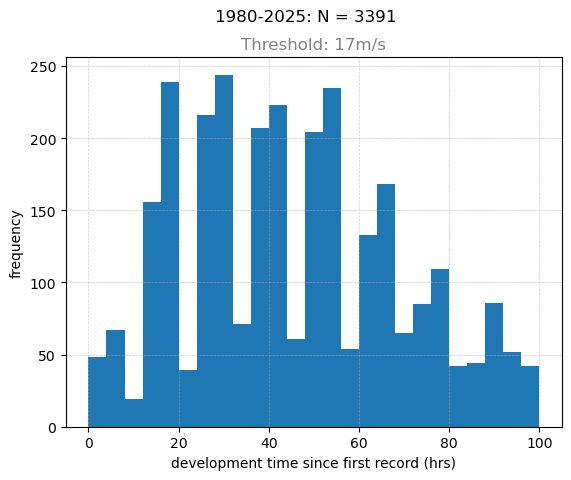

In [8]:
# print lag distribution histogram
plt.hist(lags[lags<=100], bins=25)
plt.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)
plt.suptitle('1980-2025: N = ' + str(lags.size))
plt.title("Threshold: " + str(threshold_ms) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
plt.ylabel('frequency')
plt.xlabel('development time since first record (hrs)')
plt.show()

[None, None, None, None, None, None, None, None]

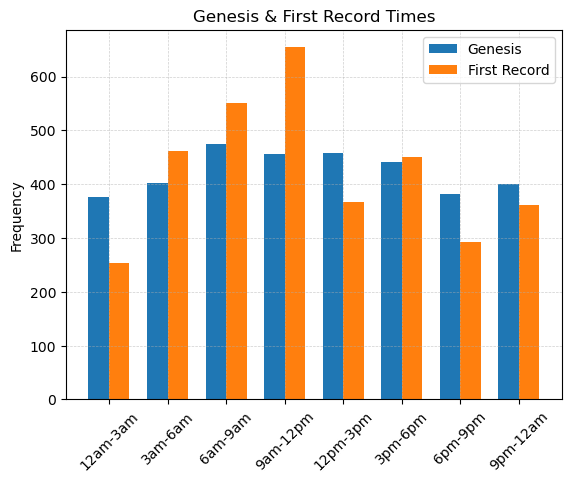

In [77]:
# First record & genesis time overlaid barplots

all_times = [gen_times, fr_times]

if num_blocks == 4:
    categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
elif num_blocks == 8:
    categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']

# Position of the bars on the x-axis
x = np.arange(len(categories))
width = 0.35  # Width of the bars

# Create the bar plot
fig, ax = plt.subplots()
ax.bar(x - width/2, gen_times, width, label='Genesis')
ax.bar(x + width/2, fr_times, width, label='First Record')

# Add labels, title, and legend
ax.set_ylabel('Frequency')
ax.set_title('Genesis & First Record Times')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(which='major', alpha=0.6, linestyle='--', linewidth=0.5)

plt.setp(ax.get_xticklabels(), rotation=45)

#### remove storms with >12 hour lag

In [7]:
def generate_data_wo_lag(threshold_ms, sindices, basin):
    threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)
    
    gen_times = []
    
    count = 0

    if basin != 'all':
        basin_ds = IBTrACS_ds.where((IBTrACS_ds['basin'] == basin) & (IBTrACS_ds.storm>=min(sindices)) & (IBTrACS_ds.storm<max(sindices)), drop=True)
        num_storms = basin_ds['storm'].size
        sindices = np.arange(1,num_storms)
    else:
        basin_ds = IBTrACS_ds
    
    # append genesis times to histogram
    for storm_index in sindices:
        count += 1
    
        # ---- Find First Record Time
        # query storm data once it turns into TC
        TSdata = basin_ds.isel(storm=storm_index) # first record
    
        # drop nan time values
        mask = ~np.isnan(TSdata['time'])
        time_clean = TSdata['time'][mask]
        
        # find storm longitude for local time conversion
        if np.isnan(TSdata['lon']).all():
            continue
        longitude = TSdata['lon'][0]
        
        # convert to hour of local time
        local_times = [to_local_time(time, longitude) for time in time_clean]
    
        # find genesis time
        first_record = to_datetime(local_times[0])
    
        # ---- Find Genesis Time
        # query storm data once it turns into TC
        TCdata = TSdata.where(TSdata['wmo_wind'] >= threshold_kts, drop=True)
    
        # find storm longitude for local time conversion
        if np.isnan(TCdata['lon']).all():
            continue
            
        longitude = TCdata['lon'][0]
    
        # convert to hour of local time
        local_times = [to_local_time(time, longitude) for time in TCdata['time']]
    
        # find genesis time
        genesis = to_datetime(local_times[0])
    
        lagtime = (genesis - first_record).total_seconds() // 3600
    
        if lagtime > 12:
            gen_times = np.append(gen_times, genesis.hour)
    
        if count % 1000 == 0:
            print(count, '/', str(len(sindices)),' searched through')
    
    return gen_times

1000 / 2566  searched through
2000 / 2566  searched through


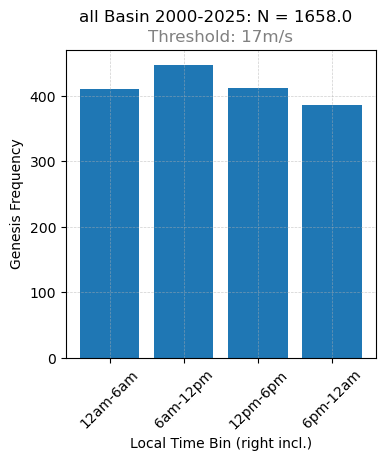

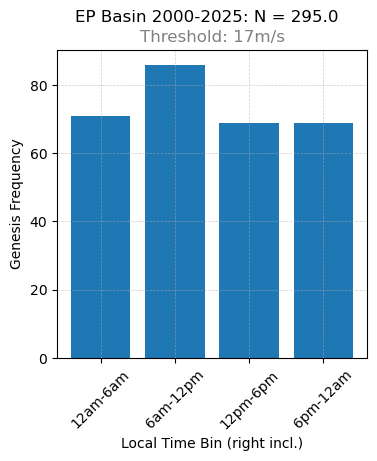

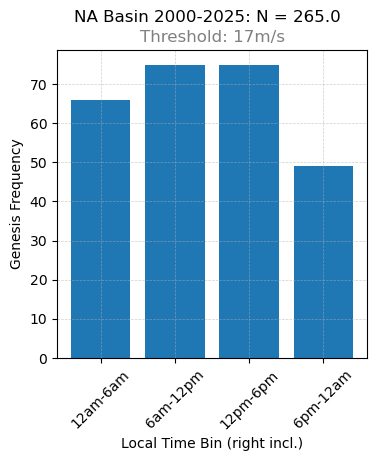

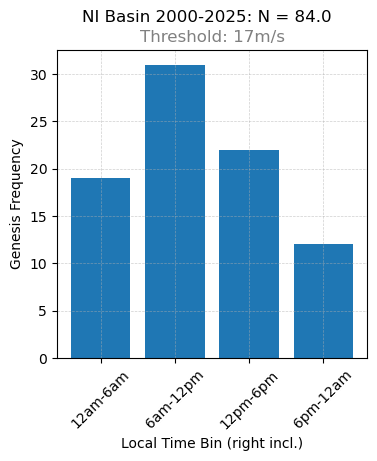

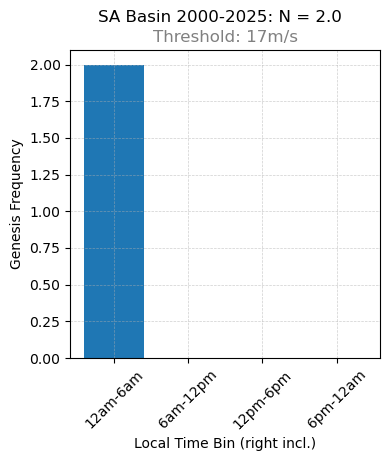

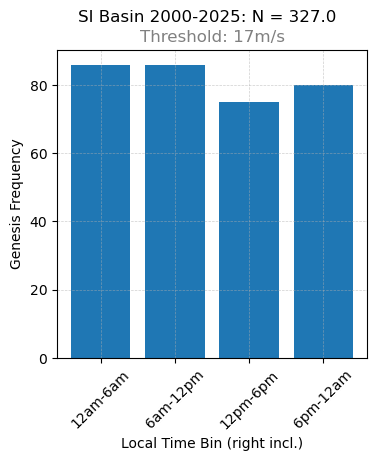

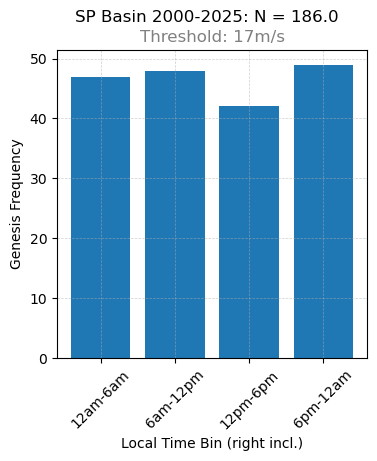

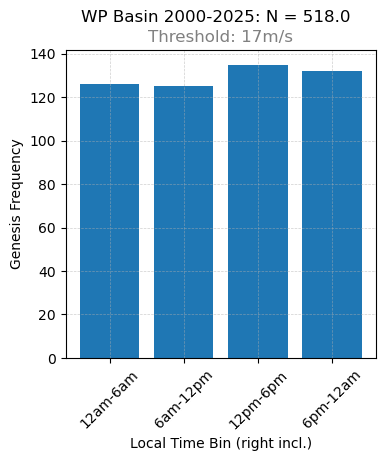

In [11]:
# All Basins
num_blocks = 4
threshold_ms = 17
sindices = np.arange(2221, 4787)
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

basins = ['all', b'EP', b'NA', b'NI', b'SA', b'SI', b'SP', b'WP']

for basin in basins:
    hist = np.zeros(num_blocks)
    
    gen_times = generate_data_wo_lag(threshold_ms, sindices, basin)

    for genesis in gen_times:
        # organize genesis hour into time block
        block = sort_genesis(num_blocks, genesis)
    
        # append to histogram
        hist[block] += 1
    
    print_hist_basin(hist, '2000-2025', num_blocks, threshold_ms, basin)

### 6 Hour Intensity Tendency

#### Current time - 6 hours ago

In [35]:
# Later: input wind vs. pressure

# user input: num_blocks (number of time blocks), threshold, hour_diff, sindices
hour_diff = 6
sindices = np.arange(1, 4787)
# ------------------------------------------------------------------------------------------------
track = 0

# initialize lag array -> later binned into a histogram
lags_w = []
lags_p = []

# append genesis times to histogram
for storm_index in sindices:
    track += 1

    # ---- Query Entire Record
    # query storm data once it turns into TC
    TSdata = IBTrACS_ds.isel(storm=storm_index) # first record

    # drop nan time values
    mask = ~np.isnan(TSdata['time'])
    time_clean = TSdata['time'][mask]
    wind_clean = TSdata['wmo_wind'][mask]
    pres_clean = TSdata['wmo_pres'][mask]

    # -- Local Time Conversion
    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue
    longitude = TSdata['lon'][0]
    
    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in time_clean]
    hours = [to_datetime(time).hour for time in local_times]

    # -- Calculate hour intensity difference
    for i in range(hour_diff-1,len(local_times)):
        lags_w = np.append(lags_w, wind_clean[i]-wind_clean[i-2]) # each index = 3 hours
        lags_p = np.append(lags_p, pres_clean[i]-wind_clean[i-2])

    if track % 1000 == 0:
        print(track, '/4787 searched through')

1000 /4787 searched through
2000 /4787 searched through
3000 /4787 searched through
4000 /4787 searched through


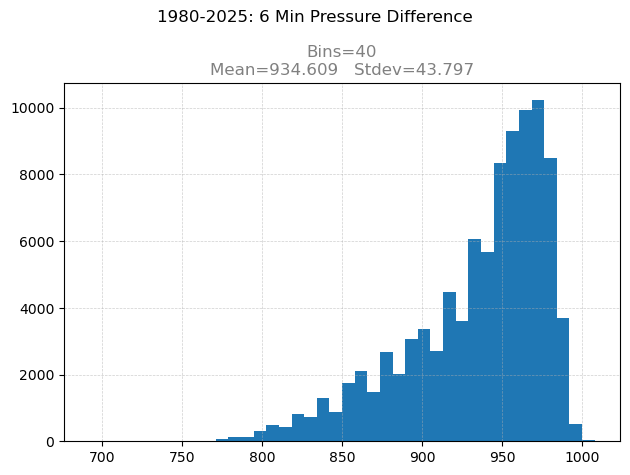

In [40]:
# Statistics
lags_mean = np.round(np.nanmean(lags_p), 3)
lags_std = np.round(np.nanstd(lags_p), 3)

# Plot
bin_count = 40
plt.hist(lags_p, bins=bin_count)
#plt.xlim(-25,25)

plt.suptitle('1980-2025: ' + str(hour_diff) + ' Min Pressure Difference')
#plt.suptitle('1980-2025: ' + str(hour_diff) + ' Wind Speed Difference')
plt.title("Bins=" + str(bin_count) + "\nMean=" + str(lags_mean) + "   Stdev=" + str(lags_std), ha='center', fontsize=12, color='gray')

plt.grid(alpha=0.6, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### Storms pre-TS
Only filter for storms that have a designation before 'TS'

4000 / 4786 databases loaded


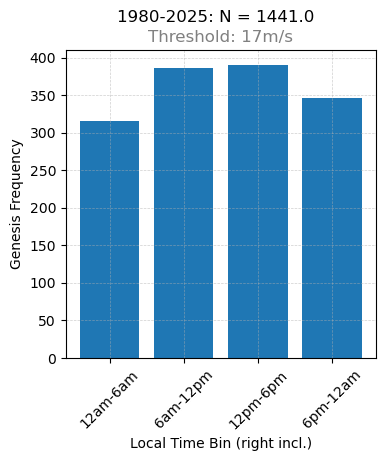

In [81]:
# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices
num_blocks = 4
threshold_ms = 17
sindices = np.arange(1, 4787)
#sindices = hilags.astype(int)
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)

count = 0

# append genesis times to histogram
for storm_index in sindices:
    count += 1

    rawdata = IBTrACS_ds.isel(storm=storm_index)

    # Apply filter
    if rawdata['nature'][0] == b'TS':
        continue
    
    # query storm data once it turns into TC
    TSdata = rawdata.where(IBTrACS_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    #if np.isnan(TSdata['lon']).all():
    #    continue

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue
    
    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block] += 1

    if count % 1000 == 0:
        print(count, "/", len(sindices), "databases loaded")

print_hist(gen_times, '1980-2025', num_blocks, threshold_ms)

#### Split by basin

100 / 528 databases loaded
200 / 528 databases loaded
500 / 528 databases loaded


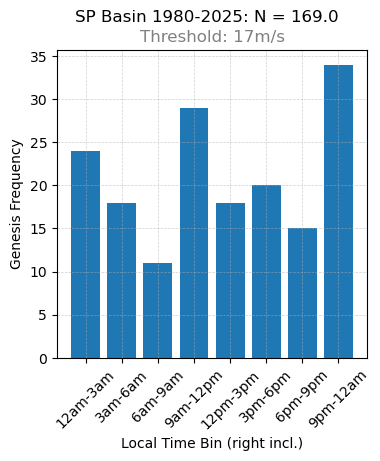

In [116]:
# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices, basin
num_blocks = 8
threshold_ms = 17
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)
sindices = np.arange(1, 4787)
basin = b'SP'
# ------------------------------------------------------------------------------------------------
# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)

count = 0

# query storms in basin
basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
num_storms = basin_ds['storm'].size

# append genesis times to histogram
for storm_index in range(num_storms):
#for storm_index in sindices:
    count += 1

    TSdata = basin_ds.isel(storm=storm_index)

    # Apply filter - skip if starting designation == 'TS'
    if TSdata['nature'][0] == b'TS':
        continue

    # turn off to get rid of hilags (lag>12hrs)
    #if (hilags==storm_index).any() != True:
    #    continue
    
    # query storm data once it turns into TC
    TSdata = TSdata.where(basin_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block] += 1

    if count % 100 == 0:
        print(count, "/", num_storms, "databases loaded")

print_hist_basin(gen_times, '1980-2025', num_blocks, threshold_ms, basin)

## Normalized Histograms
* histogram with error bars
  * by year
  * by decade
* bootstrap sampling

1000 / 4786 databases loaded
2000 / 4786 databases loaded
3000 / 4786 databases loaded


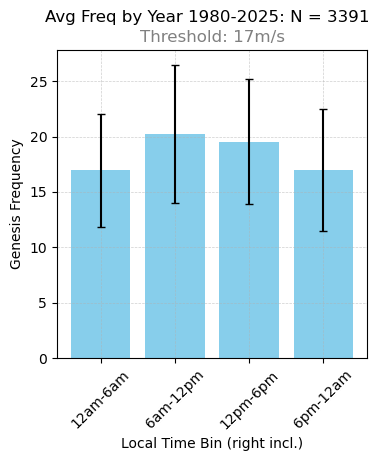

In [46]:
# Histograms by year with error bars

# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices, year
num_blocks = 4
num_years = 2025-1980+1
threshold_ms = 17
sindices = np.arange(1, 4787)
year = 1980
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

# initialize array of genesis time blocks
gen_times = np.zeros((num_blocks, num_years))

count = 0
year_id = 0

# append genesis times to histogram
for storm_index in sindices:
    
    # query storm data once it turns into TC
    TSdata = IBTrACS_ds.isel(storm=storm_index).where(IBTrACS_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]
    curr_year = to_datetime(local_times[0]).year

    # print new histogram every year
    if curr_year - year >= 1:
        
        # restart variables
        year = curr_year
        year_id += 1
        #print("year:", year)
    
    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block, year_id] += 1

    count += 1
    
    if count % 1000 == 0:
        print(count, "/", len(sindices), "databases loaded")

gen_means = np.mean(gen_times, axis=1)
gen_stds = np.std(gen_times, axis=1)
print_hist_err(gen_means, gen_stds, count, 'Annual Avg Freq 1980-2025', num_blocks, threshold_ms)

## Genesis Violin and Box Plots

In [31]:
# Generate List of Hours

# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices
threshold_ms = 17
sindices = np.arange(1, 4787)
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

gen_times = []

count = 0

# append genesis times to histogram
for storm_index in sindices:
    count += 1
    
    # query storm data once it turns into TC
    TSdata = IBTrACS_ds.isel(storm=storm_index).where(IBTrACS_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    #block = sort_genesis(num_blocks, genesis)

    # append to histogram
    #gen_times[block] += 1
    gen_times = np.append(gen_times, genesis)

    if count % 1000 == 0:
        print(count, "/", len(sindices), "databases loaded")

# Sort data into blocks
num_blocks = 8
pos = np.arange(num_blocks)
time_groups = {key:[] for key in pos.tolist()}
[time_groups[sort_genesis(num_blocks, genesis)].append(genesis) for genesis in gen_times.tolist()];

# convert 0 to 24 for violin plot
for i in range(len(time_groups[num_blocks-1])):
    hour = time_groups[num_blocks-1][i]
    if hour == 0:
        time_groups[num_blocks-1][i] = 24.0

# Decide subplot titles
if num_blocks == 4:
    categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
elif num_blocks == 8:
    categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']

1000 / 4786 databases loaded
3000 / 4786 databases loaded
4000 / 4786 databases loaded


#### Violin Plots

Text(0.5, 1.0, 'Threshold: 33m/s')

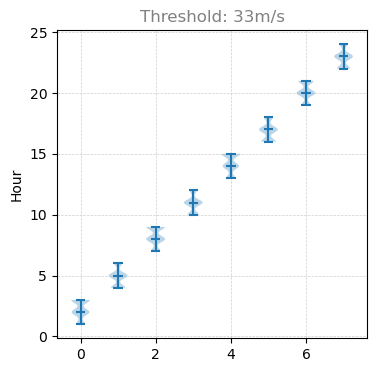

In [49]:
# --------- One plot ----------
data = [time_groups[i] for i in pos]  # ensure the order matches pos
pos = np.arange(num_blocks)

fig, ax = plt.subplots(figsize=(4,4))
ax.violinplot(data, pos, showmeans=False, showmedians=True)
ax.set_ylabel('Hour')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.set_title("Threshold: " + str(threshold_ms) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')

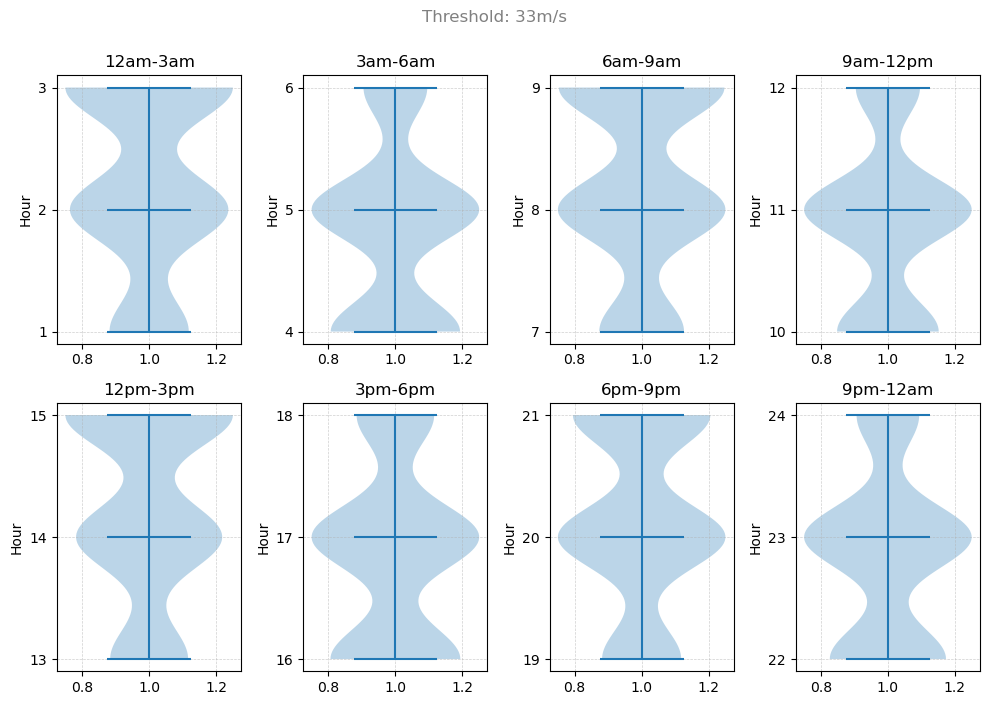

In [188]:
# --------- Subplots ----------
fig, axs = plt.subplots(nrows=2, ncols=num_blocks//2, figsize=(10,7))
row = 0
col = 0
for i in range(num_blocks):
    axs[row, col].violinplot(time_groups[i], showmeans=False, showmedians=True)
    axs[row, col].set_title(categories[i])
    axs[row, col].set_ylabel('Hour')
    axs[row, col].grid(alpha=0.6, linestyle='--', linewidth=0.5)
    
    # Set integer-only y-ticks, with appropriate range
    axs[row, col].yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # update subplot indices
    col += 1
    if i == num_blocks//2-1:
        row = 1
        col = 0

fig.suptitle("Threshold: " + str(threshold_ms) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
plt.tight_layout()

#### Box Plots

Text(0.5, 1.0, 'Threshold: 17m/s')

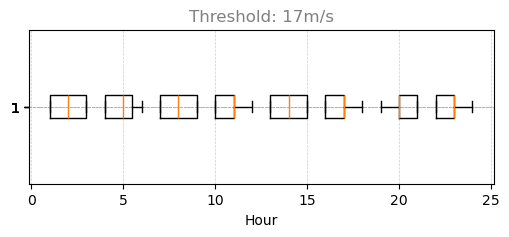

In [71]:
# --------- One plot ----------
data = [time_groups[i] for i in np.arange(num_blocks)] # unpack data

x_pos = 1  # All boxes at x = 1

fig, ax = plt.subplots(figsize=(6,2))

for i, group in enumerate(data):
    ax.boxplot(group, positions=[x_pos], vert=False)

#ax.boxplot(data, positions=[x_pos], widths=0.08, vert=False)
ax.set_xlabel('Hour')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.set_title("Threshold: " + str(threshold_ms) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')

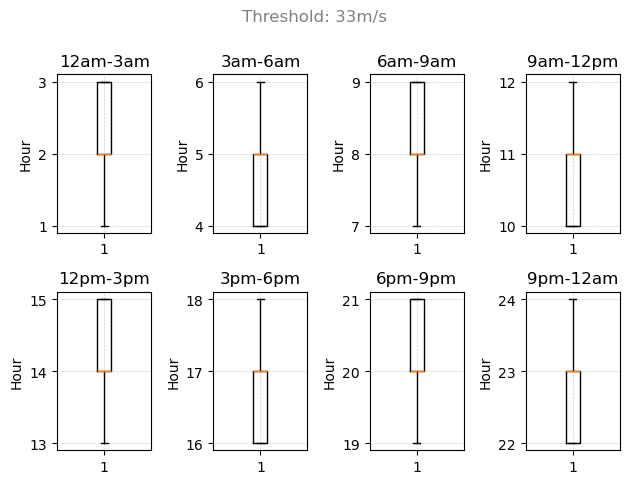

In [189]:
# --------- Subplots ----------
#from matplotlib.ticker import MaxNLocator
fig, axs = plt.subplots(nrows=2, ncols=num_blocks//2)
row = 0
col = 0
for i in range(num_blocks):
    axs[row, col].boxplot(time_groups[i])
    axs[row, col].set_title(categories[i])
    axs[row, col].set_ylabel('Hour')
    axs[row, col].grid(alpha=0.6, linestyle='--', linewidth=0.5)
    
    # Set integer-only y-ticks, with appropriate range
    axs[row, col].yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # update subplot indices
    col += 1
    if i == num_blocks//2-1:
        row = 1
        col = 0

fig.suptitle("Threshold: " + str(threshold_ms) + "m/s", ha='center', y=1.0, fontsize=12, color='gray')
plt.tight_layout()

# Split by Basin

## Manual split

### All Basins

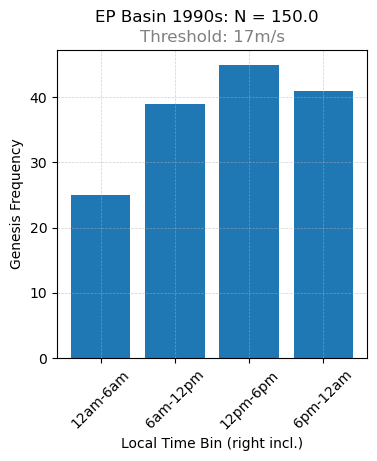

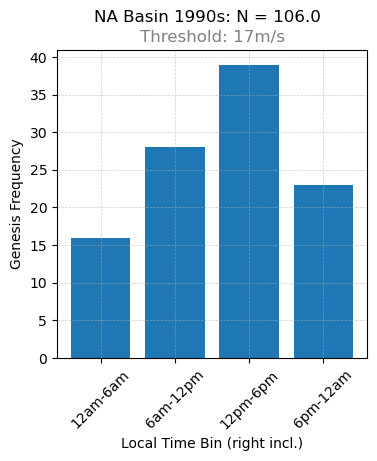

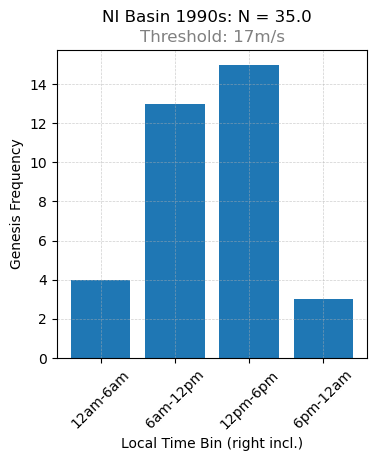

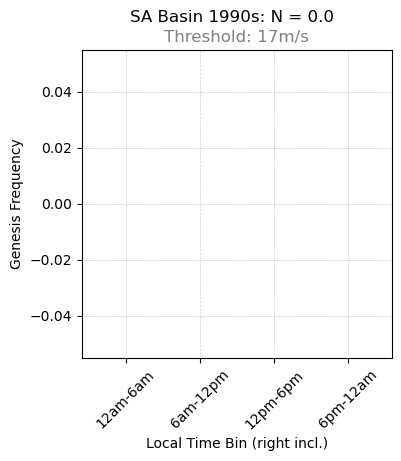

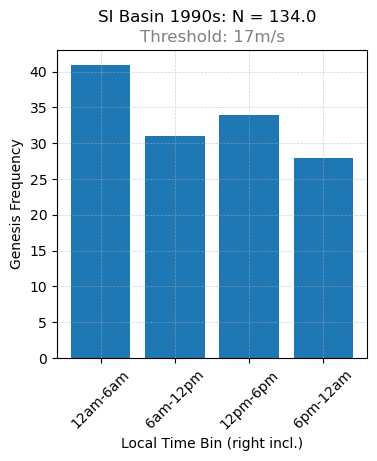

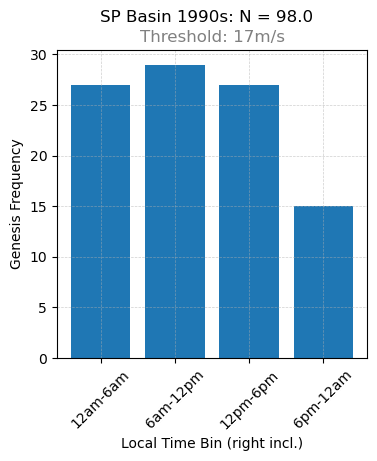

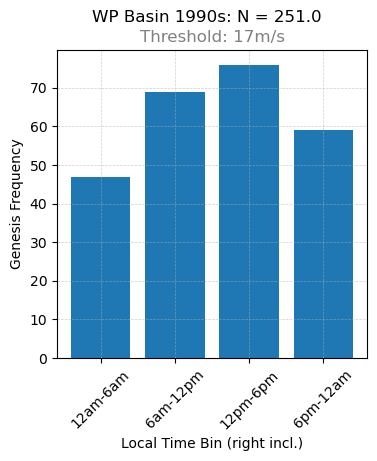

In [11]:
# All Basins
basins = [b'EP', b'NA', b'NI', b'SA', b'SI', b'SP', b'WP']
# ------------------------------------------------------------------------------------------------
# user input: num_blocks (number of time blocks), threshold_ms in m/s, start_index (starting year), basin
num_blocks = 4
threshold_ms = 17
start_index = 1131
stop_index = 2221
#basin = b'NA'
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

for basin in basins:
    # initialize array of genesis time blocks
    gen_times = np.zeros(num_blocks)
    
    count = 0

    # query storms in year
    filtered_years = IBTrACS_ds.where((IBTrACS_ds.storm>=start_index) & (IBTrACS_ds.storm<stop_index), drop=True)
    
    # query storms in basin
    basin_ds = filtered_years.where(filtered_years['basin'] == basin, drop=True)
    num_storms = basin_ds['storm'].size
    
    # append genesis times to histogram
    for storm_index in range(num_storms):
    #for storm_index in sindices:
        count += 1
    
        TSdata = basin_ds.isel(storm=storm_index)
        
        '''
        if TSdata['basin'][0] != basin: # is there a faster way to do this?
            continue
        '''
        
        # query storm data once it turns into TC
        TSdata = TSdata.where(basin_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)
    
        # find storm longitude for local time conversion
        if np.isnan(TSdata['lon']).all():
            continue
    
        longitude = TSdata['lon'][0]
    
        # convert to hour of local time
        local_times = [to_local_time(time, longitude) for time in TSdata['time']]
        hours = [to_datetime(time).hour for time in local_times]
    
        # find genesis time
        genesis = hours[0]
    
        # organize genesis hour into time block
        block = sort_genesis(num_blocks, genesis)
    
        # append to histogram
        gen_times[block] += 1
    
        #if count % 500 == 0:
        #    print(count, "/", num_storms, "databases loaded")
    
    print_hist_basin(gen_times, '1990s', num_blocks, threshold_ms, basin)

### Box plots

In [41]:
# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices, basin
num_blocks = 8
threshold_ms = 17
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)
sindices = np.arange(1, 4787)
basin = b'EP'
# ------------------------------------------------------------------------------------------------
# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)

count = 0

# query storms in basin
basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
num_storms = basin_ds['storm'].size

# append genesis times to histogram
for storm_index in range(num_storms):
#for storm_index in sindices:

    TSdata = basin_ds.isel(storm=storm_index)
    
    '''
    if TSdata['basin'][0] != basin: # is there a faster way to do this?
        continue
    '''
    
    # query storm data once it turns into TC
    TSdata = TSdata.where(basin_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = hours[0]
    
    gen_times = np.append(gen_times, genesis)

    count += 1
    if count % 100 == 0:
        print(count, "/", num_storms, "databases loaded")

# Sort data into blocks
num_blocks = 8
pos = np.arange(num_blocks)
time_groups = {key:[] for key in pos.tolist()}
[time_groups[sort_genesis(num_blocks, genesis)].append(genesis) for genesis in gen_times.tolist()];

# convert 0 to 24 for violin plot
for i in range(len(time_groups[num_blocks-1])):
    hour = time_groups[num_blocks-1][i]
    if hour == 0:
        time_groups[num_blocks-1][i] = 24.0

# Decide subplot titles
if num_blocks == 4:
    categories = ['12am-6am', '6am-12pm', '12pm-6pm', '6pm-12am']
elif num_blocks == 8:
    categories = ['12am-3am', '3am-6am', '6am-9am', '9am-12pm', '12pm-3pm', '3pm-6pm', '6pm-9pm', '9pm-12am']

100 / 1100 databases loaded
200 / 1100 databases loaded
300 / 1100 databases loaded
400 / 1100 databases loaded
500 / 1100 databases loaded
600 / 1100 databases loaded


Text(0.5, 0.9, 'Threshold: 17m/s')

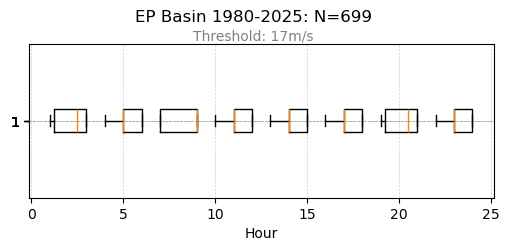

In [42]:
# --------- One plot ----------
data = [time_groups[i] for i in np.arange(num_blocks)] # unpack data

x_pos = 1  # All boxes at x = 1

fig, ax = plt.subplots(figsize=(6,2))

for i, group in enumerate(data):
    ax.boxplot(group, positions=[x_pos], vert=False)

#ax.boxplot(data, positions=[x_pos], widths=0.08, vert=False)
ax.set_xlabel('Hour')
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

fig.suptitle(basin.decode("utf-8") + ' Basin ' + '1980-2025: N=' + str(count), y=1.05)
fig.text(0.5, 0.9, "Threshold: " + str(threshold_ms) + "m/s", ha='center', color='gray')

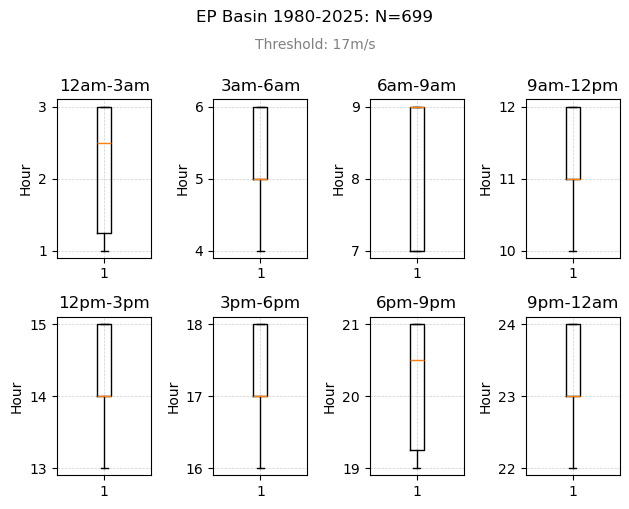

In [43]:
# --------- Subplots ----------
fig, axs = plt.subplots(nrows=2, ncols=num_blocks//2)
row = 0
col = 0
for i in range(num_blocks):
    axs[row, col].boxplot(time_groups[i])
    axs[row, col].set_title(categories[i])
    axs[row, col].set_ylabel('Hour')
    axs[row, col].grid(alpha=0.6, linestyle='--', linewidth=0.5)
    
    # Set integer-only y-ticks, with appropriate range
    axs[row, col].yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # update subplot indices
    col += 1
    if i == num_blocks//2-1:
        row = 1
        col = 0

#ax.set_title( ha='center', y=1.0, fontsize=12, color='gray')
fig.suptitle(basin.decode("utf-8") + ' Basin ' + '1980-2025: N=' + str(count), y=1.05)
fig.text(0.5, 0.97, "Threshold: " + str(threshold_ms) + "m/s", ha='center', color='gray')

plt.tight_layout()

### One basin

100 / 528 databases loaded
500 / 528 databases loaded


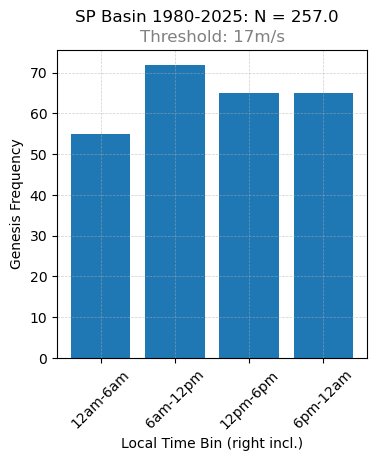

In [114]:
# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices, basin
num_blocks = 4
threshold_ms = 17
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)
sindices = np.arange(1, 4787)
basin = b'SP'
# ------------------------------------------------------------------------------------------------
# initialize array of genesis time blocks
gen_times = np.zeros(num_blocks)

count = 0

# query storms in basin
basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
num_storms = basin_ds['storm'].size

# append genesis times to histogram
for storm_index in range(num_storms):
#for storm_index in sindices:
    count += 1

    TSdata = basin_ds.isel(storm=storm_index)

    # turn off to get rid of hilags (lag>12hrs)
    if (hilags==storm_index).any() != True:
        continue
    
    # query storm data once it turns into TC
    TSdata = TSdata.where(basin_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]

    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block] += 1

    if count % 100 == 0:
        print(count, "/", num_storms, "databases loaded")

print_hist_basin(gen_times, '1980-2025', num_blocks, threshold_ms, basin)

#### Normalized histogram

1000 / 4786 databases loaded


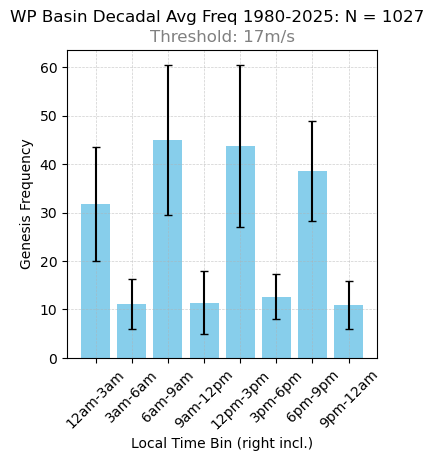

In [78]:
# Histograms by decade with error bars

# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices, year
num_blocks = 8
num_decades = 5
threshold_ms = 17
sindices = np.arange(1, 4787)
year = 1980
basin = b'WP'
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

# initialize array of genesis time blocks
gen_times = np.zeros((num_blocks, num_decades))

count = 0
decade = 0

basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
num_storms = basin_ds['storm'].size

# append genesis times to histogram
for storm_index in range(num_storms):
    
    # query storm data once it turns into TC
    TSdata = basin_ds.isel(storm=storm_index).where(basin_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]
    curr_year = to_datetime(local_times[0]).year

    # print new histogram every X years
    if curr_year - year >= 10:
        
        # restart variables
        year = curr_year
        decade += 1
        #print("year:", year)
    
    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block, decade] += 1

    count += 1
    
    if count % 1000 == 0:
        print(count, "/", len(sindices), "databases loaded")

gen_means = np.mean(gen_times, axis=1)
gen_stds = np.std(gen_times, axis=1)
print_hist_err(gen_means, gen_stds, count, basin.decode("utf-8") + ' Basin Decadal Avg Freq 1980-2025', num_blocks, threshold_ms)

1000 / 4786 databases loaded


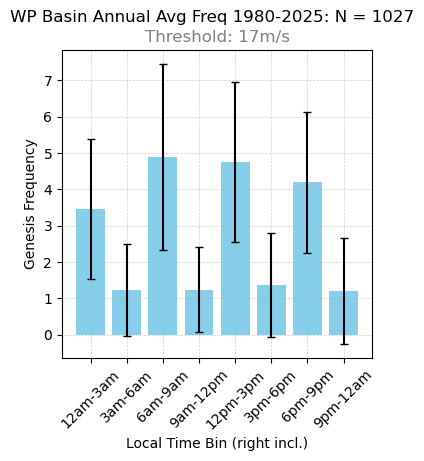

In [79]:
# Histograms by year with error bars

# user input: num_blocks (number of time blocks), threshold_ms in m/s, sindices, year
num_blocks = 8
num_years = 2025-1980+1
threshold_ms = 17
sindices = np.arange(1, 4787)
year = 1980
basin = b'WP'
# ------------------------------------------------------------------------------------------------
threshold_kts = threshold_ms*2.2369 # convert to kts aka mph (IBTrACS unit)

# initialize array of genesis time blocks
gen_times = np.zeros((num_blocks, num_years))

count = 0
year_id = 0

basin_ds = IBTrACS_ds.where(IBTrACS_ds['basin'] == basin, drop=True)
num_storms = basin_ds['storm'].size

# append genesis times to histogram
for storm_index in range(num_storms):
    
    # query storm data once it turns into TC
    TSdata = basin_ds.isel(storm=storm_index).where(basin_ds.isel(storm=storm_index)['wmo_wind'] >= threshold_kts, drop=True)

    # find storm longitude for local time conversion
    if np.isnan(TSdata['lon']).all():
        continue

    longitude = TSdata['lon'][0]

    # convert to hour of local time
    local_times = [to_local_time(time, longitude) for time in TSdata['time']]
    hours = [to_datetime(time).hour for time in local_times]
    curr_year = to_datetime(local_times[0]).year

    # print new histogram every year
    if curr_year - year >= 1:
        
        # restart variables
        year = curr_year
        year_id += 1
        #print("year:", year)
    
    # find genesis time
    genesis = hours[0]

    # organize genesis hour into time block
    block = sort_genesis(num_blocks, genesis)

    # append to histogram
    gen_times[block, year_id] += 1

    count += 1
    
    if count % 1000 == 0:
        print(count, "/", len(sindices), "databases loaded")

gen_means = np.mean(gen_times, axis=1)
gen_stds = np.std(gen_times, axis=1)
print_hist_err(gen_means, gen_stds, count, basin.decode("utf-8") + ' Basin Annual Avg Freq 1980-2025', num_blocks, threshold_ms)